In [1]:
# ============================================
# BLOCO 1: IMPORTAÇÕES E CONFIGURAÇÕES INICIAIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import warnings
warnings.filterwarnings('ignore')

# Configurações para reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

print("✅ Bibliotecas importadas com sucesso!")
print(f"   TensorFlow version: {tf.__version__}")
print(f"   XGBoost version: {xgb.__version__}")

✅ Bibliotecas importadas com sucesso!
   TensorFlow version: 2.21.0
   XGBoost version: 3.2.0


In [2]:
# ============================================
# BLOCO 2: CARREGAR E PREPARAR OS DADOS
# ============================================

# Carregar os dados
df = pd.read_csv('./1.Dados/noticias.csv')

print(f"📊 Total de notícias: {len(df)}")
print(f"📋 Colunas: {df.columns.tolist()}")
print("\n🔍 Primeiras linhas:")
display(df.head())

# Verificar valores nulos
print("\n🔍 Valores nulos por coluna:")
print(df.isnull().sum())

# Preencher valores nulos na coluna de texto
df['texto_sem_stopwords'] = df['texto_sem_stopwords'].fillna('')

📊 Total de notícias: 2000
📋 Colunas: ['titulo', 'data', 'visitas', 'texto', 'texto_limpo', 'texto_sem_stopwords']

🔍 Primeiras linhas:


,titulo,data,visitas,texto,texto_limpo,texto_sem_stopwords
0,STJD indefere pedido de suspensão e Abel Ferre...,11/4/2026 16:47,141,O Palmeiras terá uma nova rodada de desafios n...,o palmeiras tera uma nova rodada de desafios n...,palmeiras nova rodada desafios campeonato bras...
1,Nubank Anuncia Amistoso Imperdível: Palmeiras ...,11/4/2026 16:47,129,O Nubank está explorando a possibilidade de or...,o nubank esta explorando a possibilidade de or...,nubank explorando possibilidade organizar amis...
2,STJD Recusa Suspensão de Abel Ferreira; Palmei...,11/4/2026 16:47,105,A Sociedade Esportiva Palmeiras manifestou sua...,a sociedade esportiva palmeiras manifestou sua...,sociedade esportiva palmeiras manifestou insat...
3,Palmeiras encerra treinos para o Dérbi com Vit...,11/4/2026 14:27,276,"Na manhã deste sábado (11), a Academia de Fute...",na manha deste sabado 11 a academia de futebol...,manha deste sabado 11 academia futebol palco u...
4,Messi Pode Anunciar Amistoso Histórico em São ...,11/4/2026 14:07,246,"A co-fundadora do Nubank, Cristina Junqueira, ...",a co fundadora do nubank cristina junqueira re...,co fundadora nubank cristina junqueira revelou...



🔍 Valores nulos por coluna:
titulo                  0
data                    0
visitas                 0
texto                  18
texto_limpo            18
texto_sem_stopwords    18
dtype: int64


In [3]:
# ============================================
# BLOCO 3: CRIAR VARIÁVEL TARGET
# ============================================

# Definir o threshold: 20% das notícias com mais visitas
threshold = np.percentile(df['visitas'], 80)  # 80º percentil = top 20%

# Criar a variável target: 1 = Hot (top 20%), 0 = Not Hot
df['hot'] = (df['visitas'] >= threshold).astype(int)

print(f"\n🎯 Threshold para ser considerado HOT: {threshold:.0f} visitas")
print(f"\n📈 Distribuição da variável target:")
print(df['hot'].value_counts())
print(f"   Hot (1): {df['hot'].sum()} notícias ({df['hot'].mean()*100:.1f}%)")
print(f"   Not Hot (0): {len(df) - df['hot'].sum()} notícias ({(1-df['hot'].mean())*100:.1f}%)")


🎯 Threshold para ser considerado HOT: 1879 visitas

📈 Distribuição da variável target:
hot
0    1600
1     400
Name: count, dtype: int64
   Hot (1): 400 notícias (20.0%)
   Not Hot (0): 1600 notícias (80.0%)



📊 Estatísticas de visitas por categoria:


,count,mean,std,min,25%,50%,75%,max
hot,,,,,,,,
0,1600.0,919.141875,402.680581,105.0,618.00,849.0,1170.75,1878.0
1,400.0,4722.007500,6479.717975,1884.0,2166.75,2926.5,4844.25,85839.0


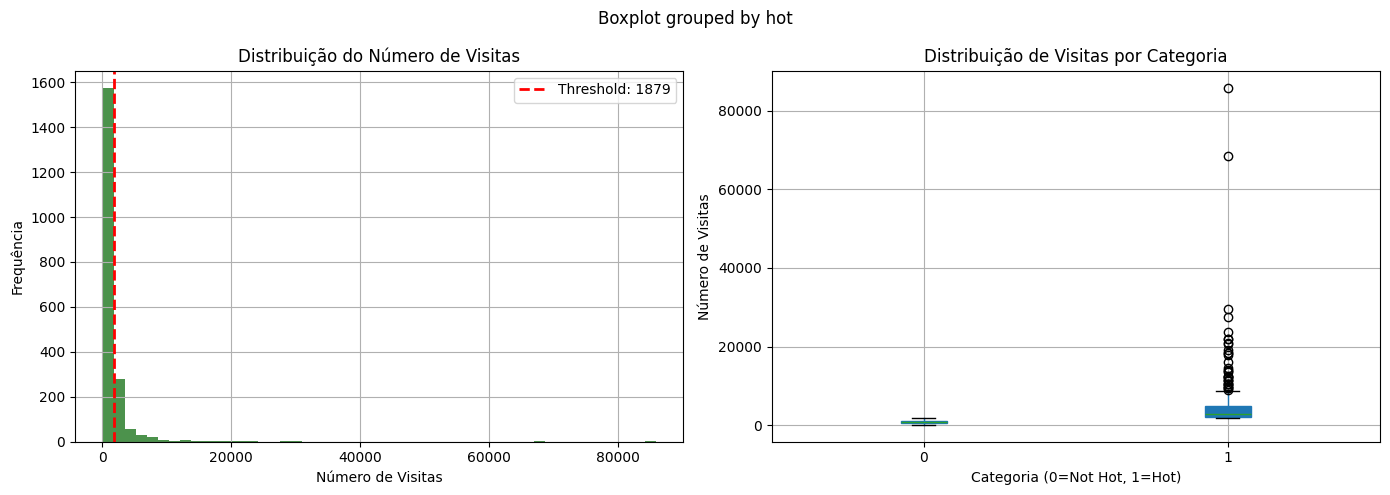


🏆 TOP 10 NOTÍCIAS MAIS VISITADAS:


,titulo,visitas,hot
1673,Mais reforços a caminho? Palmeiras aproveita f...,85839,1
1651,REFORÇO DE PESO! Palmeiras acerta a contrataçã...,68550,1
914,PREMIAÇÃO ASTRONÔMICA: Confira quanto o Palmei...,29481,1
1477,Palmeiras recebe proposta astronômica por Vito...,27657,1
1367,Venda milionária? Palmeiras recebe propostas p...,23760,1
743,Palmeiras negocia pacote do Zenit com Wendel e...,21999,1
165,Palmeiras posta vídeo fazendo provocação a Rog...,21939,1
1038,Presidente dos Estados Unidos exalta o Palmeir...,20889,1
1567,Palmeiras e Guarani se enfrentam na 8ª rodada ...,20688,1
227,Bahia x Palmeiras; Saiba onde assistir,19209,1


In [4]:
# ============================================
# BLOCO 4: ANÁLISE EXPLORATÓRIA INICIAL
# ============================================

# Estatísticas básicas das visitas por categoria
print("\n📊 Estatísticas de visitas por categoria:")
display(df.groupby('hot')['visitas'].describe())

# Visualização da distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição das visitas
ax1 = axes[0]
df['visitas'].hist(bins=50, ax=ax1, color='darkgreen', alpha=0.7)
ax1.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.0f}')
ax1.set_xlabel('Número de Visitas')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição do Número de Visitas')
ax1.legend()

# Boxplot por categoria
ax2 = axes[1]
df.boxplot(column='visitas', by='hot', ax=ax2, patch_artist=True)
ax2.set_xlabel('Categoria (0=Not Hot, 1=Hot)')
ax2.set_ylabel('Número de Visitas')
ax2.set_title('Distribuição de Visitas por Categoria')

plt.tight_layout()
plt.show()

# Top 10 notícias mais visitadas
print("\n🏆 TOP 10 NOTÍCIAS MAIS VISITADAS:")
top_10 = df.nlargest(10, 'visitas')[['titulo', 'visitas', 'hot']]
display(top_10)

In [5]:
# ============================================
# BLOCO 5: DIVISÃO DOS DADOS
# ============================================

X = df['texto_sem_stopwords']
y = df['hot']

# Primeiro separar treino (60%) e temporário (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Depois dividir o temporário em validação (20%) e teste (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n📊 Divisão dos dados:")
print(f"   Treino: {len(X_train)} notícias ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Validação: {len(X_val)} notícias ({len(X_val)/len(df)*100:.1f}%)")
print(f"   Teste: {len(X_test)} notícias ({len(X_test)/len(df)*100:.1f}%)")

# Verificar a distribuição da target em cada conjunto
print("\n🎯 Distribuição da target em cada conjunto:")
print(f"   Treino - Hot: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Validação - Hot: {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"   Teste - Hot: {y_test.sum()} ({y_test.mean()*100:.1f}%)")


📊 Divisão dos dados:
   Treino: 1200 notícias (60.0%)
   Validação: 400 notícias (20.0%)
   Teste: 400 notícias (20.0%)

🎯 Distribuição da target em cada conjunto:
   Treino - Hot: 240 (20.0%)
   Validação - Hot: 80 (20.0%)
   Teste - Hot: 80 (20.0%)


In [6]:
# ============================================
# BLOCO 6: TF-IDF VECTORIZER
# ============================================

# Criar o vetorizador TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,  # Limitar a 5000 palavras mais importantes
    min_df=2,           # Ignorar palavras que aparecem em menos de 2 documentos
    max_df=0.8,         # Ignorar palavras que aparecem em mais de 80% dos documentos
    ngram_range=(1, 2)  # Usar unigramas e bigramas
)

# Ajustar o vetorizador nos dados de TREINO e transformar todos os conjuntos
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"\n📊 Dimensão da matriz TF-IDF: {X_train_tfidf.shape}")
print(f"   Número de features (palavras): {X_train_tfidf.shape[1]}")

# Exibir algumas palavras importantes
feature_names = tfidf.get_feature_names_out()
print(f"\n📝 Exemplo de palavras importantes: {feature_names[:20]}")

# Verificar a esparsidade
density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"\n📊 Densidade da matriz TF-IDF: {density:.4%}")


📊 Dimensão da matriz TF-IDF: (1200, 5000)
   Número de features (palavras): 5000

📝 Exemplo de palavras importantes: ['00' '02' '03' '04' '10' '10 milhoes' '10 pontos' '100'
 '100 aproveitamento' '109' '109 gols' '10a' '10a rodada' '11' '11 dias'
 '11 jogos' '11 milhoes' '11 pontos' '11 titulos' '11a']

📊 Densidade da matriz TF-IDF: 3.5406%


In [7]:
# ============================================
# BLOCO 7: FUNÇÕES AUXILIARES PARA AVALIAÇÃO
# ============================================

def evaluate_model(model, X_test, y_test, model_name="Modelo"):
    """Avalia um modelo e retorna as métricas principais"""
    y_pred = model.predict(X_test)
    
    # Verificar se o modelo tem predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None
    
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc
    }
    
    print(f"\n{'='*60}")
    print(f"📊 RESULTADOS - {model_name}")
    print(f"{'='*60}")
    print(f"   Acurácia:    {metrics['accuracy']:.4f}")
    print(f"   Precisão:    {metrics['precision']:.4f}")
    print(f"   Recall:      {metrics['recall']:.4f}")
    print(f"   F1-Score:    {metrics['f1']:.4f}")
    if roc_auc:
        print(f"   ROC-AUC:     {metrics['roc_auc']:.4f}")
    print(f"\n📋 Relatório de Classificação:")
    print(classification_report(y_test, y_pred, target_names=['Not Hot', 'Hot']))
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Hot', 'Hot'], 
                yticklabels=['Not Hot', 'Hot'])
    plt.title(f'Matriz de Confusão - {model_name}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.show()
    
    # Curva ROC (se disponível)
    if roc_auc:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}')
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - {model_name}')
        plt.legend()
        plt.show()
    
    return metrics

def get_top_features(model, feature_names, n=20):
    """Retorna as features mais importantes de um modelo"""
    if hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    elif hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        return None
    
    indices = np.argsort(importances)[::-1][:n]
    top_features = [(feature_names[i], importances[i]) for i in indices]
    return top_features

print("✅ Funções auxiliares definidas!")

✅ Funções auxiliares definidas!



🚀 TREINANDO MODELO 1: REGRESSÃO LOGÍSTICA

📊 Acurácia na Validação (Regressão Logística base): 0.8125

🔍 Otimizando hiperparâmetros...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

✅ Melhores parâmetros: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
✅ Melhor F1-Score (validação): 0.4967

📊 RESULTADOS - Regressão Logística Otimizada
   Acurácia:    0.7525
   Precisão:    0.4078
   Recall:      0.5250
   F1-Score:    0.4590
   ROC-AUC:     0.7235

📋 Relatório de Classificação:
              precision    recall  f1-score   support

     Not Hot       0.87      0.81      0.84       320
         Hot       0.41      0.53      0.46        80

    accuracy                           0.75       400
   macro avg       0.64      0.67      0.65       400
weighted avg       0.78      0.75      0.76       400



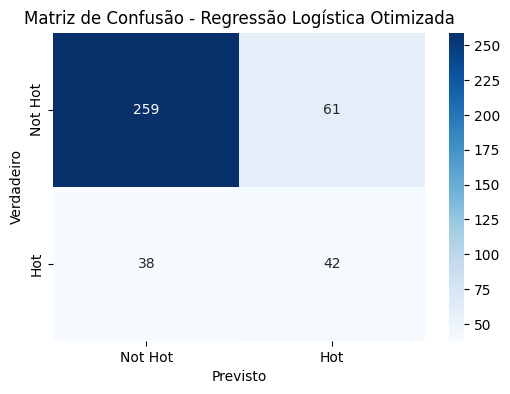

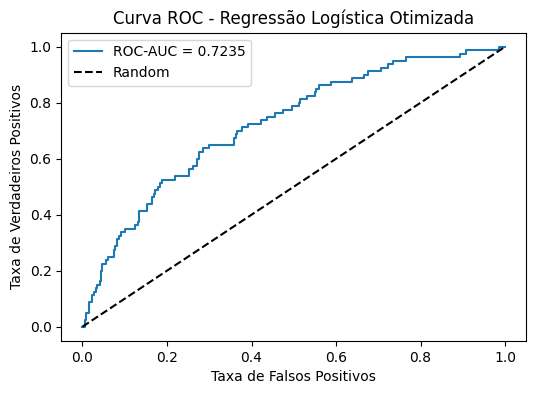

In [8]:
# ============================================
# BLOCO 8: REGRESSÃO LOGÍSTICA
# ============================================

print("\n" + "="*70)
print("🚀 TREINANDO MODELO 1: REGRESSÃO LOGÍSTICA")
print("="*70)

# Primeiro modelo sem otimização
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

# Avaliar no conjunto de validação
y_val_pred = lr.predict(X_val_tfidf)
print(f"\n📊 Acurácia na Validação (Regressão Logística base): {accuracy_score(y_val, y_val_pred):.4f}")

# Otimização de hiperparâmetros com GridSearch
print("\n🔍 Otimizando hiperparâmetros...")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', None]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train_tfidf, y_train)

print(f"\n✅ Melhores parâmetros: {grid_lr.best_params_}")
print(f"✅ Melhor F1-Score (validação): {grid_lr.best_score_:.4f}")

# Modelo otimizado
lr_optimized = grid_lr.best_estimator_

# Avaliar o modelo otimizado
metrics_lr = evaluate_model(lr_optimized, X_test_tfidf, y_test, "Regressão Logística Otimizada")


🌳 TREINANDO MODELO 2: RANDOM FOREST

📊 Acurácia na Validação (Random Forest base): 0.8075

🔍 Otimizando hiperparâmetros...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Melhores parâmetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced_subsample'}
✅ Melhor F1-Score (validação): 0.3940

📊 RESULTADOS - Random Forest Otimizado
   Acurácia:    0.7325
   Precisão:    0.3483
   Recall:      0.3875
   F1-Score:    0.3669
   ROC-AUC:     0.7181

📋 Relatório de Classificação:
              precision    recall  f1-score   support

     Not Hot       0.84      0.82      0.83       320
         Hot       0.35      0.39      0.37        80

    accuracy                           0.73       400
   macro avg       0.60      0.60      0.60       400
weighted avg       0.74      0.73      0.74       400



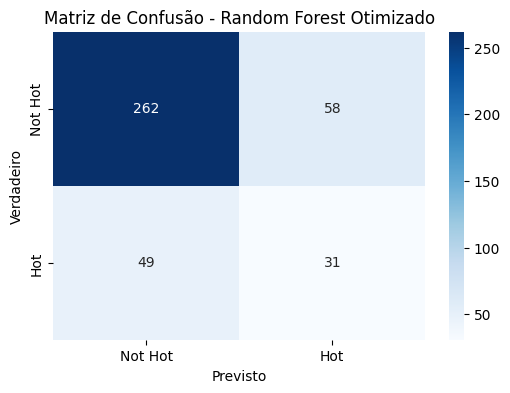

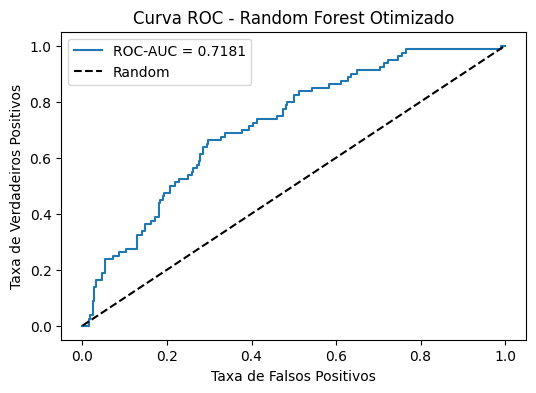


🏆 Top 20 palavras mais importantes (Random Forest):
   1. 'posicao': 0.0068
   2. 'resultado': 0.0065
   3. 'janela': 0.0057
   4. 'assistir': 0.0054
   5. 'gestao': 0.0051
   6. 'campeonato': 0.0050
   7. 'diretoria': 0.0049
   8. 'bastidores': 0.0044
   9. 'crucial': 0.0042
   10. 'pic': 0.0042
   11. 'sobre': 0.0039
   12. 'desempenho coletivo': 0.0039
   13. 'lideranca campeonato': 0.0037
   14. 'internamente': 0.0036
   15. 'junior': 0.0036
   16. 'desempenho': 0.0036
   17. 'apos': 0.0036
   18. 'euros': 0.0035
   19. 'diario': 0.0035
   20. 'nino': 0.0034


In [10]:
# ============================================
# BLOCO 9: RANDOM FOREST
# ============================================

print("\n" + "="*70)
print("🌳 TREINANDO MODELO 2: RANDOM FOREST")
print("="*70)

# Modelo base
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)

# Avaliar no conjunto de validação
y_val_pred = rf.predict(X_val_tfidf)
print(f"\n📊 Acurácia na Validação (Random Forest base): {accuracy_score(y_val, y_val_pred):.4f}")

# Otimização de hiperparâmetros com RandomizedSearch
print("\n🔍 Otimizando hiperparâmetros...")
param_dist_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist_rf,
    n_iter=30,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_rf.fit(X_train_tfidf, y_train)

print(f"\n✅ Melhores parâmetros: {random_rf.best_params_}")
print(f"✅ Melhor F1-Score (validação): {random_rf.best_score_:.4f}")

# Modelo otimizado
rf_optimized = random_rf.best_estimator_

# Avaliar o modelo otimizado
metrics_rf = evaluate_model(rf_optimized, X_test_tfidf, y_test, "Random Forest Otimizado")

# Feature Importance
top_features_rf = get_top_features(rf_optimized, tfidf.get_feature_names_out(), n=20)
if top_features_rf:
    print(f"\n🏆 Top 20 palavras mais importantes (Random Forest):")
    for i, (word, importance) in enumerate(top_features_rf, 1):
        print(f"   {i}. '{word}': {importance:.4f}")

In [9]:
import tabicl

print(tabicl.__version__)

AttributeError: partially initialized module 'torch' has no attribute 'fx' (most likely due to a circular import)

In [2]:
# ============================================
# BLOCO EXTRA: TabICL (In-Context Learning)
# ============================================
# Instalação (rode uma vez no Colab):
# !pip install tabicl

from tabicl import TabICLClassifier
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*70)
print("🤖 TREINANDO MODELO EXTRA: TabICL (In-Context Learning)")
print("="*70)

# TabICL opera sobre features densas — usar a matriz TF-IDF convertida para array denso
# AVISO: com 5000 features isso pode ser pesado; reduzir dimensionalidade ajuda
from sklearn.decomposition import TruncatedSVD

print("\n📉 Reduzindo dimensionalidade com SVD (TF-IDF → 200 componentes)...")
svd = TruncatedSVD(n_components=200, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

print(f"   Shape treino após SVD: {X_train_svd.shape}")
print(f"   Variância explicada: {svd.explained_variance_ratio_.sum():.2%}")

# Instanciar e treinar o TabICL
# kv_cache=True acelera muito quando o conjunto de treino é fixo
tabicl = TabICLClassifier(kv_cache=True)

print("\n🔄 Ajustando TabICL (download do checkpoint na 1ª vez)...")
tabicl.fit(X_train_svd, y_train.values)

# Predições no conjunto de teste
print("🔍 Gerando predições no conjunto de teste...")
y_pred_tabicl = tabicl.predict(X_test_svd)
y_prob_tabicl = tabicl.predict_proba(X_test_svd)[:, 1]

# Métricas
acc  = accuracy_score(y_test, y_pred_tabicl)
prec = precision_score(y_test, y_pred_tabicl, zero_division=0)
rec  = recall_score(y_test, y_pred_tabicl, zero_division=0)
f1   = f1_score(y_test, y_pred_tabicl, zero_division=0)
auc  = roc_auc_score(y_test, y_prob_tabicl)

print(f"\n{'='*60}")
print(f"📊 RESULTADOS - TabICL")
print(f"{'='*60}")
print(f"   Acurácia:    {acc:.4f}")
print(f"   Precisão:    {prec:.4f}")
print(f"   Recall:      {rec:.4f}")
print(f"   F1-Score:    {f1:.4f}")
print(f"   ROC-AUC:     {auc:.4f}")
print(f"\n📋 Relatório de Classificação:")
print(classification_report(y_test, y_pred_tabicl, target_names=['Not Hot', 'Hot']))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_tabicl)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Hot', 'Hot'],
            yticklabels=['Not Hot', 'Hot'])
plt.title('Matriz de Confusão - TabICL')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_tabicl)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='purple', label=f'ROC-AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - TabICL')
plt.legend()
plt.tight_layout()
plt.show()

# Salvar métricas no mesmo formato dos outros modelos
metrics_tabicl = {
    'model': 'TabICL',
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'roc_auc': auc
}

AttributeError: partially initialized module 'torch' has no attribute '_logging' (most likely due to a circular import)